# VGG 16 MODEL

# PREPARATION

**CONNECTING GOOGLE DRIVE**

Reason:

This project is used the google colab. Then, there can connect with google drive for data usage.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**IMPORT LIBRARY**

In [ ]:
import os
import cv2
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from google.colab import drive
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# VGG 16

**LOADING PRETRAINED VGG16 BASE MODEL**



In [ ]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


**FREEZE BASE MODEL**

Freeze all convoluotional layers for feature extraction phase.

In [ ]:
vgg_base.trainable = False

# PREPROCESSING

**CUSTOM CLASSIFICATION HEAD**

Add fully connected layers on top of VGG16 for binary classification

 (BENIGN : 0; MALIGNANT : 1)

In [ ]:
x = GlobalAveragePooling2D()(vgg_base.output)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

predictions = Dense(1, activation='sigmoid')(x)

**DEFINE DATASET PATH**

In [ ]:
base_dataset = "/content/drive/MyDrive/Data"

**PREPARE DATA GENERATORS**

Apply preprocessing


*   Enhance training performance


Augmentation


*   Prevent overfitting



Validation split


*   Split data for train and validate




In [ ]:
img_size = (256, 256)
batch_size = 12

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.12,
    horizontal_flip=False,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_dataset,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    base_dataset,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1748 images belonging to 2 classes.
Found 436 images belonging to 2 classes.


# PHASE 1

**COMPUTE CLASS WEIGHTS**

Handle imbalance class during training.

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.8927477017364658), 1: np.float64(1.1365409622886866)}


**DEFINE TRAINING CALLBACKS**

lr_scheduler



*   Reduce learning rate



early_stop




*   Stop early when accuracy did not increase. The advantages which is epochs can set high.



In [ ]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**COMPILE PHASE 1 MODEL**

Train the custom classifier layers only



*   Learning rate: 1e-3 (0.001)
*   Evaluation metric:
    *   Accuracy





In [ ]:
vgg_model = Model(inputs=vgg_base.input, outputs=predictions)

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**TRAINING PHASE 1: FEATURE EXTRACTION**

Train classification head while base layers remain frozen with value:



*   Epochs : 20
*   Class weights
*   Call back
    *   lr_schedular
    *   early_stop







In [ ]:
vgg_history = vgg_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.5898 - loss: 0.7684 - val_accuracy: 0.4885 - val_loss: 0.9597 - learning_rate: 0.0010
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 143s 981ms/step - accuracy: 0.6430 - loss: 0.6622 - val_accuracy: 0.6147 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.6293 - loss: 0.6556 - val_accuracy: 0.5413 - val_loss: 0.7329 - learning_rate: 0.0010
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 146s 997ms/step - accuracy: 0.6482 - loss: 0.6432 - val_accuracy: 0.6216 - val_loss: 0.6496 - learning_rate: 0.0010
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.6482 - loss: 0.6321 - val_accuracy: 0.5757 - val_loss: 0.6754 - learning_rate: 0.0010
Epoch 6/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 144s 981ms/step - accuracy: 0.6653 - loss: 0.6054 - val_accuracy: 0.6216 - val_loss: 0.6321 - learning_rate: 0.0010
Epoch 7/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.6630 -

**Save phase 1 model in .h5 format.**

In [ ]:
vgg_model.save("/content/drive/MyDrive/VGG16phase1version6.h5")
print("Model saved successfully")

Model saved successfully


# PHASE 2

**UNFREEZE FROM TOP VGG16 LAYERS**

Preparing process (Unfreeze 4 layers) the model for fine-tuning.

In [ ]:
for layer in vgg_base.layers[-4:]:
    layer.trainable = True

**RECOMPILE MODEL FOR PHAE 2**

Using a lower learning rate for fine-tuning.

In [ ]:
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

**TRAIN PHASE 2: FINE-TUNING**

Fine-tune for the selected from upper layers of VGG16.

In [ ]:
fine_tune_history = vgg_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.6831 - auc: 0.7499 - loss: 0.5940 - val_accuracy: 0.6284 - val_auc: 0.6698 - val_loss: 0.6516 - learning_rate: 1.0000e-05
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.7265 - auc: 0.7935 - loss: 0.5513 - val_accuracy: 0.6468 - val_auc: 0.7164 - val_loss: 0.6492 - learning_rate: 1.0000e-05
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - accuracy: 0.7304 - auc: 0.8099 - loss: 0.5324
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
146/146 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.7168 - auc: 0.8001 - loss: 0.5412 - val_accuracy: 0.5940 - val_auc: 0.6725 - val_loss: 0.6776 - learning_rate: 1.0000e-05
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 143s 982ms/step - accuracy: 0.7403 - auc: 0.8154 - loss: 0.5239 - val_accuracy: 0.6239 - val_auc: 0.7047 - val_loss: 0.6533 - learning_rate: 5.0000e-06
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 144s 984ms/step - accuracy: 0.7609

**SAVE FINAL (PHASE 2) MODEL**

save the model after fine-tuning.

In [ ]:
vgg_model.save("/content/drive/MyDrive/VGG16phase2version6.h5")
print("Model saved successfully")

Model saved successfully


# EVALUATION

**GENERATE PREDICTION AND CLASSIFICATION REPORT**

Evaluate model performance on validation data

In [ ]:
# predictions
pred_probs = vgg_model.predict(val_generator)
pred_labels = (pred_probs > 0.5).astype(int)

# true labels
true_labels = val_generator.classes

print(classification_report(true_labels, pred_labels))
print(confusion_matrix(true_labels, pred_labels))

37/37 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step
              precision    recall  f1-score   support

           0       0.73      0.64      0.68       244
           1       0.60      0.70      0.65       192

    accuracy                           0.67       436
   macro avg       0.67      0.67      0.66       436
weighted avg       0.67      0.67      0.67       436

[[155  89]
 [ 57 135]]


**APPLY CUSTOM THRESHOLD**

Adjust prediction threshold for class assignment.

In [ ]:
pred_labels = (pred_probs > 0.4).astype(int)

**PLOT CONDUSION MATRIX**

Data visualization for classification results with using **heatmap**.

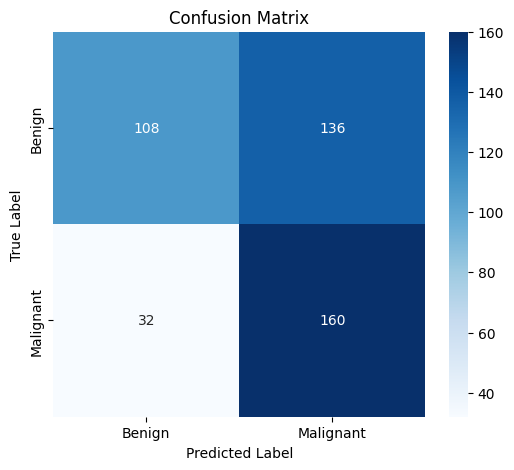

In [ ]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

**PLOT PHASE 1 TRAINING HISTORY**

Display metrics for training and validation


*   Accuracy
*   Loss



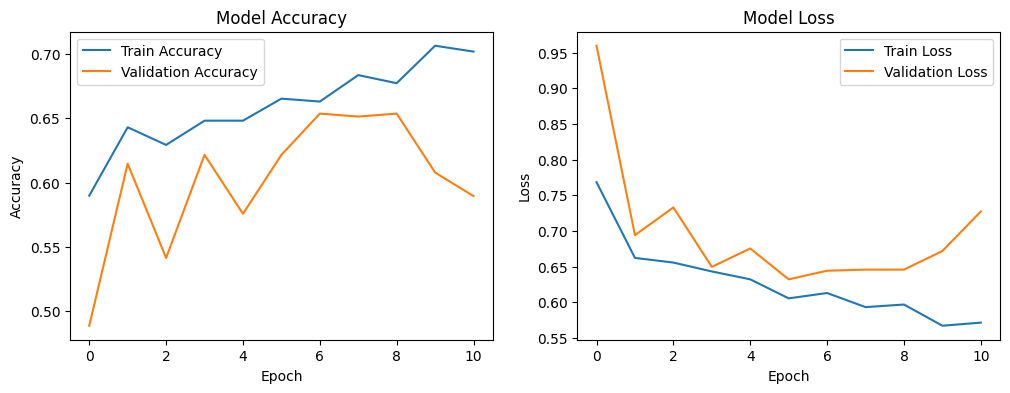

In [ ]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(vgg_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**PLOT COMBINED TRAINING STRATEGY (PHASE 1 & PHASE 1)**

Plot the accuracy and loss of the phase 1 and phase 2 into one graph.

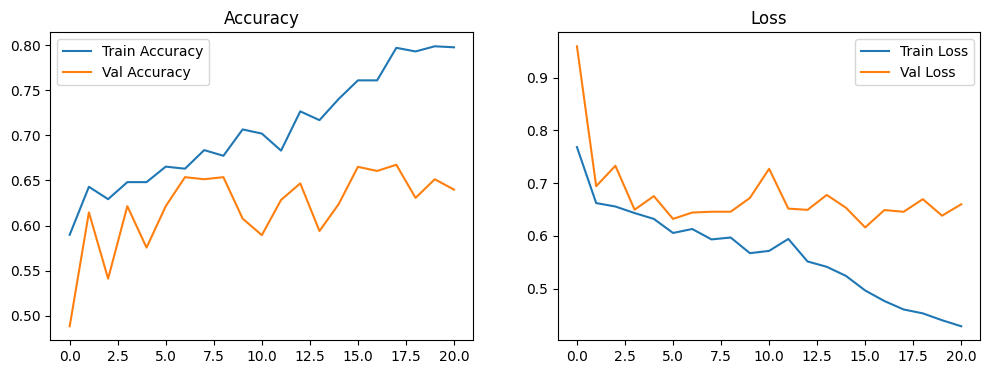

In [ ]:
acc = vgg_history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = vgg_history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

loss = vgg_history.history['loss'] + fine_tune_history.history['loss']
val_loss = vgg_history.history['val_loss'] + fine_tune_history.history['val_loss']

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(acc,label='Train Accuracy')
plt.plot(val_acc,label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label='Train Loss')
plt.plot(val_loss,label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

**PLOT ROC CURVE**

Measure the model's ability to seperate 2 classses (False positive & True positive)

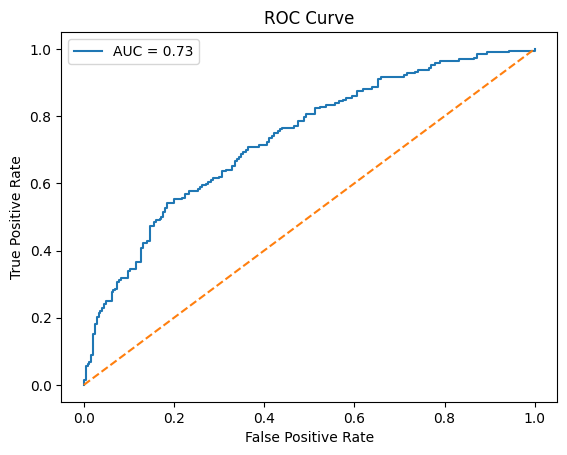

In [ ]:
fpr, tpr, _ = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**DISPLAY MODEL SUMMARY**

View the final architecture of the trained model.

In [ ]:
vgg_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,44

 Total params: 29,319,109 (111.84 MB)

 Trainable params: 7,227,777 (27.57 MB)

 Non-trainable params: 7,635,776 (29.13 MB)

 Optimizer params: 14,455,556 (55.14 MB)

**USED FOR CLEAR TENSORFLOW SESSION**

Release memory after training and evaluation.

In [ ]:
K.clear_session()